In [1]:
import pandas as pd
import numpy as np

In [2]:
prev_df = pd.read_excel(r"D:\OneDrive - Nilons Enterprises Pvt Ltd\Desktop\Anadi\Data\YTD 2024-2025 NC_E2.xlsx")
curr_df = pd.read_excel(r"D:\OneDrive - Nilons Enterprises Pvt Ltd\Desktop\Anadi\Data\SAP_apr1st_may31st_NCE2.xlsx")

🚀 Distributor Product Recommendation System
🔍 Starting Comprehensive Distributor Recommendation Analysis
📊 Data Preparation Phase
------------------------------
✅ Previous Year Data: 208061 records
✅ Current Year Data: 31701 records
📅 Previous Year Date Range: 2024-04-04 00:00:00 to 2025-03-31 00:00:00
📅 Current Year Date Range: 2025-04-06 00:00:00 to 2025-05-31 00:00:00
📊 May 2024 records: 17810
📊 April-May 2025 records: 31701
📊 Unique distributors in prev_df: 866
📊 Unique distributors in curr_df: 608
📊 Unique products in prev_df: 1382
📊 Unique products in curr_df: 894

🌊 Seasonality Analysis
------------------------------


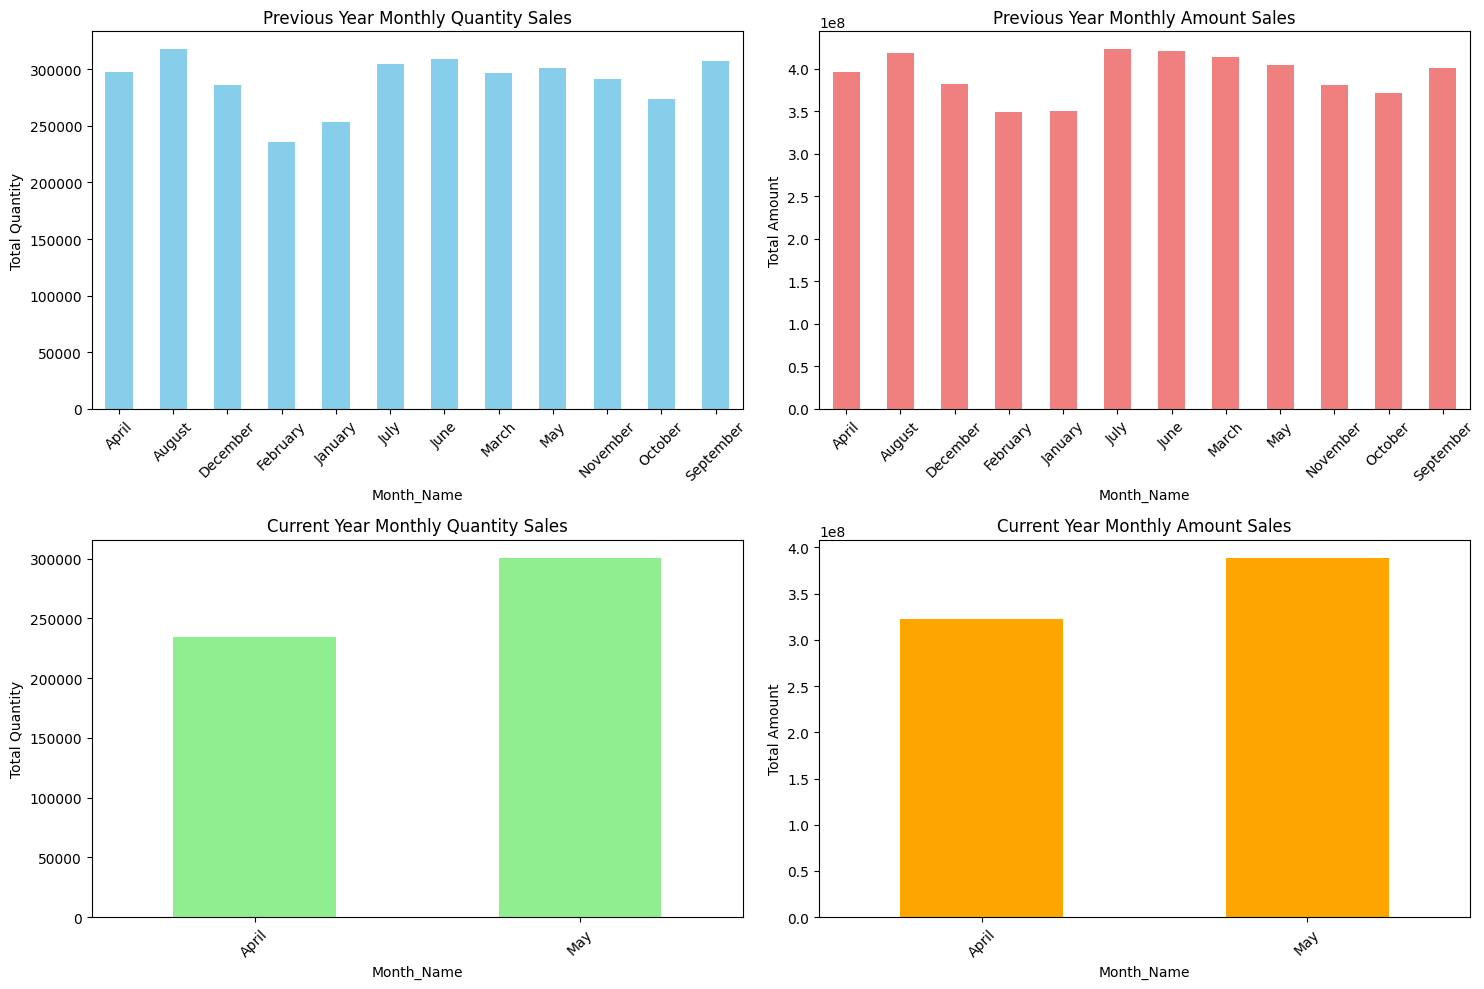


🎯 Calculating Recommendation Scores
------------------------------
📊 Data Distribution Analysis:
   • Records with May 2024 sales > 0: 11028
   • Records with recent sales > 0: 14960
   • Records with both periods having sales: 0
   • Seasonality ratio > 1.2: 0
   • Seasonality ratio > 1.0: 0
   • Using fallback criteria (any May 2024 sales)
✅ Total product-distributor combinations analyzed: 25990
✅ Prime recommendations identified: 11028

🏪 Distributor Performance Analysis
------------------------------


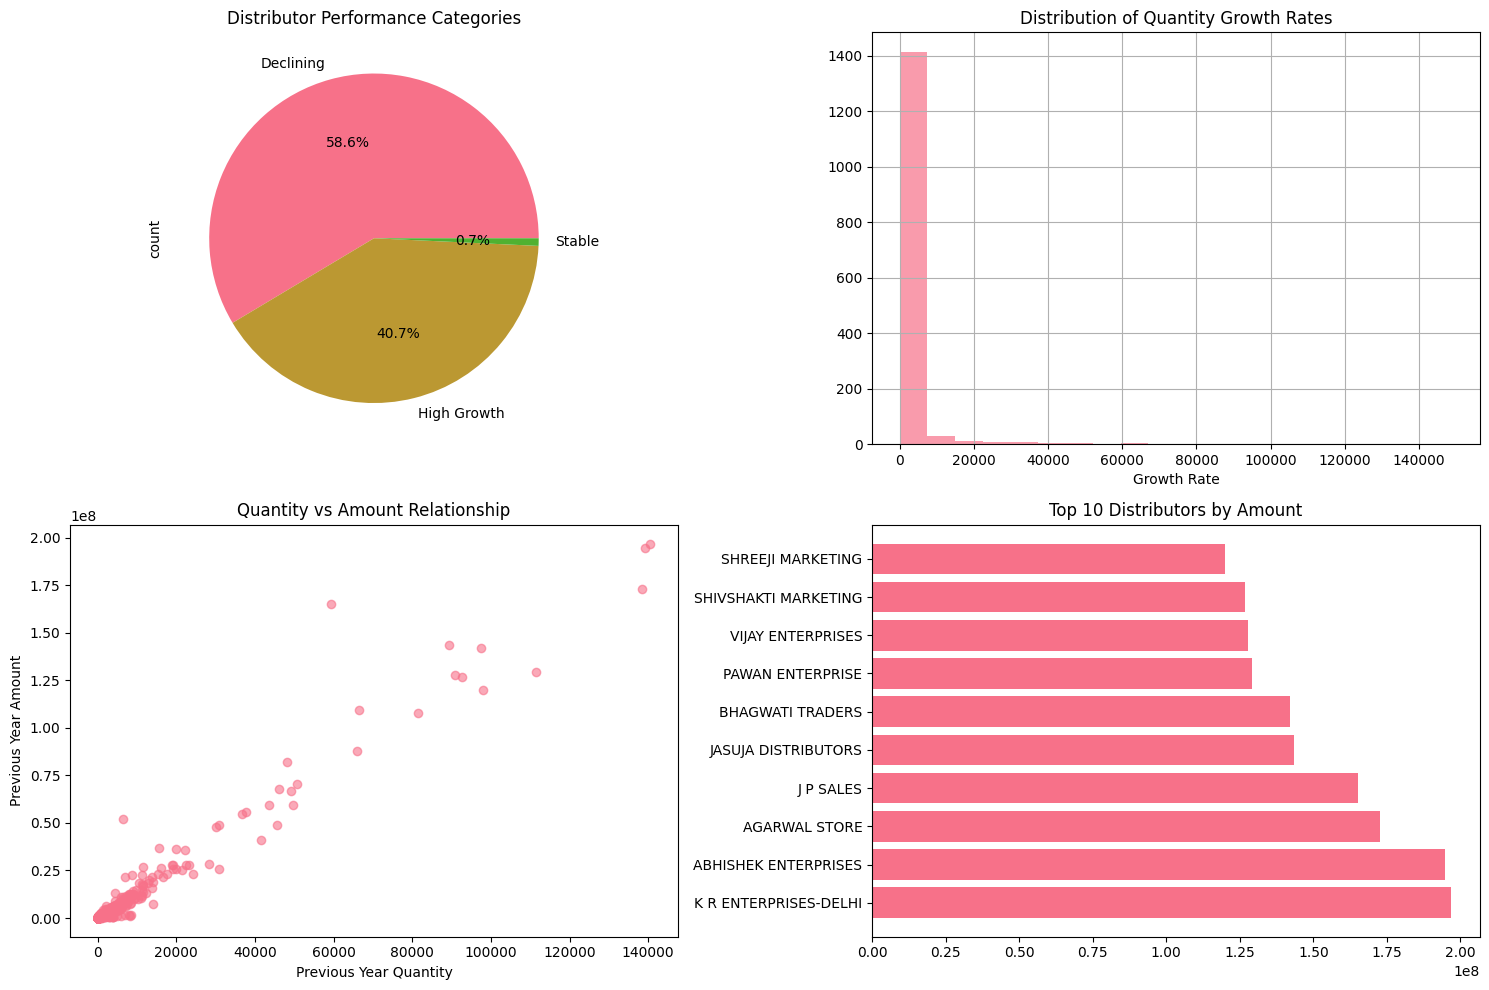


🎯 Generating Personalized Recommendations
------------------------------
📊 Actionable recommendations pool: 27211 records
✅ Generated recommendations for 1064 distributors

📋 Top 10 Distributor Recommendations Summary

🏪 Distributor: MAHALAXMI BAKERY (Code: 100006)
📊 Performance Category: Declining
🎯 Top Product Recommendations:
   1. 15 KG 5-6 MM PAPAYA FRUIT PRESERVED RED POU (KARAC (1400919.0)
      • Seasonality Ratio: 0.00
      • Expected Increase: 160 units
      • Last May Sales: 160 units
      • Recent Avg: 0 units/month
      • Recommendation Score: nan

🏪 Distributor: MODEL BAKERS AND CONFECTIONERS (Code: 100007)
📊 Performance Category: Declining
🎯 Top Product Recommendations:
   1. 15 KG MODEL PAPAYA FRUIT PRESERVE MIX POU (1400845.0)
      • Seasonality Ratio: 0.00
      • Expected Increase: 300 units
      • Last May Sales: 300 units
      • Recent Avg: 0 units/month
      • Recommendation Score: nan

🏪 Distributor: RAM BAKERY (Code: 100013)
📊 Performance Category: Decl

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime, timedelta
import warnings
warnings.filterwarnings('ignore')

# Set up plotting style
plt.style.use('default')
sns.set_palette("husl")

print("🚀 Distributor Product Recommendation System")
print("=" * 50)

# Load the data (assuming prev_df and curr_df are already loaded)
# For this analysis, we'll work with the assumption that the dataframes are available

def load_and_prepare_data(prev_df, curr_df):
    """
    Prepare and clean the data for analysis
    """
    print("📊 Data Preparation Phase")
    print("-" * 30)
    
    # Standardize column names between datasets
    prev_df_clean = prev_df.copy()
    curr_df_clean = curr_df.copy()
    
    # Rename columns to match
    column_mapping = {
        'Channel': 'Distribution Channel',
        'CATEGORY': 'Material Group', 
        'VARIANTS': 'Material Sub Group',
        'Qty': 'Invoice Qty',
        'Billing Amount': 'Bill Amount'
    }
    
    for old_col, new_col in column_mapping.items():
        if old_col in prev_df_clean.columns:
            prev_df_clean = prev_df_clean.rename(columns={old_col: new_col})
    
    # Convert Invoice Date to datetime
    prev_df_clean['Invoice Date'] = pd.to_datetime(prev_df_clean['Invoice Date'])
    curr_df_clean['Invoice Date'] = pd.to_datetime(curr_df_clean['Invoice Date'])
    
    # Convert key columns to string to avoid merge issues
    prev_df_clean['C. No'] = prev_df_clean['C. No'].astype(str)
    prev_df_clean['Item Code'] = prev_df_clean['Item Code'].astype(str)
    curr_df_clean['C. No'] = curr_df_clean['C. No'].astype(str)
    curr_df_clean['Item Code'] = curr_df_clean['Item Code'].astype(str)
    
    # Add year-month columns for easier analysis
    prev_df_clean['Year_Month'] = prev_df_clean['Invoice Date'].dt.to_period('M')
    curr_df_clean['Year_Month'] = curr_df_clean['Invoice Date'].dt.to_period('M')
    
    # Add month name for seasonality analysis
    prev_df_clean['Month_Name'] = prev_df_clean['Invoice Date'].dt.month_name()
    curr_df_clean['Month_Name'] = curr_df_clean['Invoice Date'].dt.month_name()
    
    print(f"✅ Previous Year Data: {len(prev_df_clean)} records")
    print(f"✅ Current Year Data: {len(curr_df_clean)} records")
    
    # Debug: Check date ranges
    print(f"📅 Previous Year Date Range: {prev_df_clean['Invoice Date'].min()} to {prev_df_clean['Invoice Date'].max()}")
    print(f"📅 Current Year Date Range: {curr_df_clean['Invoice Date'].min()} to {curr_df_clean['Invoice Date'].max()}")
    
    # Check for May data specifically
    may_2024_records = len(prev_df_clean[prev_df_clean['Month_Name'] == 'May'])
    recent_records = len(curr_df_clean[curr_df_clean['Month_Name'].isin(['April', 'May'])])
    print(f"📊 May 2024 records: {may_2024_records}")
    print(f"📊 April-May 2025 records: {recent_records}")
    
    # Check unique distributors and products
    print(f"📊 Unique distributors in prev_df: {prev_df_clean['C. No'].nunique()}")
    print(f"📊 Unique distributors in curr_df: {curr_df_clean['C. No'].nunique()}")
    print(f"📊 Unique products in prev_df: {prev_df_clean['Item Code'].nunique()}")
    print(f"📊 Unique products in curr_df: {curr_df_clean['Item Code'].nunique()}")
    
    return prev_df_clean, curr_df_clean

def analyze_seasonality_patterns(prev_df, curr_df):
    """
    Analyze seasonal patterns in sales data
    """
    print("\n🌊 Seasonality Analysis")
    print("-" * 30)
    
    # Monthly sales patterns from previous year
    monthly_sales_prev = prev_df.groupby(['Month_Name']).agg({
        'Invoice Qty': 'sum',
        'Bill Amount': 'sum',
        'Item Code': 'nunique'
    }).round(2)
    
    # Current year monthly sales (Apr-May 2025)
    monthly_sales_curr = curr_df.groupby(['Month_Name']).agg({
        'Invoice Qty': 'sum',
        'Bill Amount': 'sum',
        'Item Code': 'nunique'
    }).round(2)
    
    # Create visualization
    fig, axes = plt.subplots(2, 2, figsize=(15, 10))
    
    # Previous year monthly quantity
    monthly_sales_prev['Invoice Qty'].plot(kind='bar', ax=axes[0,0], color='skyblue')
    axes[0,0].set_title('Previous Year Monthly Quantity Sales')
    axes[0,0].set_ylabel('Total Quantity')
    axes[0,0].tick_params(axis='x', rotation=45)
    
    # Previous year monthly amount
    monthly_sales_prev['Bill Amount'].plot(kind='bar', ax=axes[0,1], color='lightcoral')
    axes[0,1].set_title('Previous Year Monthly Amount Sales')
    axes[0,1].set_ylabel('Total Amount')
    axes[0,1].tick_params(axis='x', rotation=45)
    
    # Current year monthly quantity
    if len(monthly_sales_curr) > 0:
        monthly_sales_curr['Invoice Qty'].plot(kind='bar', ax=axes[1,0], color='lightgreen')
        axes[1,0].set_title('Current Year Monthly Quantity Sales')
        axes[1,0].set_ylabel('Total Quantity')
        axes[1,0].tick_params(axis='x', rotation=45)
        
        # Current year monthly amount
        monthly_sales_curr['Bill Amount'].plot(kind='bar', ax=axes[1,1], color='orange')
        axes[1,1].set_title('Current Year Monthly Amount Sales')
        axes[1,1].set_ylabel('Total Amount')
        axes[1,1].tick_params(axis='x', rotation=45)
    
    plt.tight_layout()
    plt.show()
    
    return monthly_sales_prev, monthly_sales_curr

def calculate_recommendation_scores(prev_df, curr_df):
    """
    Calculate recommendation scores based on seasonality and recent trends
    """
    print("\n🎯 Calculating Recommendation Scores")
    print("-" * 30)
    
    # Get May 2024 data (same month last year)
    may_2024_data = prev_df[prev_df['Month_Name'] == 'May'].groupby(['C. No', 'C. Name', 'Item Code', 'Item Name']).agg({
        'Invoice Qty': 'sum',
        'Bill Amount': 'sum',
        'Gross Weight': 'sum'
    }).reset_index()
    may_2024_data.columns = ['C. No', 'C. Name', 'Item Code', 'Item Name', 'May_2024_Qty', 'May_2024_Amount', 'May_2024_Weight']
    
    # Get April-May 2025 data (last 2 months)
    recent_data = curr_df.groupby(['C. No', 'C. Name', 'Item Code', 'Item Name']).agg({
        'Invoice Qty': 'sum',
        'Bill Amount': 'sum',
        'Gross Weight': 'sum'
    }).reset_index()
    recent_data.columns = ['C. No', 'C. Name', 'Item Code', 'Item Name', 'Recent_Qty', 'Recent_Amount', 'Recent_Weight']
    
    # Calculate average monthly quantity for recent period
    recent_data['Avg_Monthly_Recent_Qty'] = recent_data['Recent_Qty'] / 2  # Dividing by 2 months
    
    # Merge datasets
    recommendation_df = pd.merge(may_2024_data, recent_data, 
                                on=['C. No', 'C. Name', 'Item Code', 'Item Name'], 
                                how='outer').fillna(0)
    
    # Calculate recommendation score
    # Score = (May_2024_Qty / Avg_Monthly_Recent_Qty) - 1
    # Higher score means May 2024 was much higher than recent average
    recommendation_df['Seasonality_Ratio'] = np.where(
        recommendation_df['Avg_Monthly_Recent_Qty'] > 0,
        recommendation_df['May_2024_Qty'] / recommendation_df['Avg_Monthly_Recent_Qty'],
        0
    )
    
    # Calculate additional metrics
    recommendation_df['Growth_Potential'] = recommendation_df['May_2024_Qty'] - recommendation_df['Avg_Monthly_Recent_Qty']
    recommendation_df['Value_Score'] = recommendation_df['May_2024_Amount'] / (recommendation_df['May_2024_Qty'] + 1)  # Average value per unit
    
    # Normalize scores for better interpretation
    recommendation_df['Normalized_Seasonality'] = (recommendation_df['Seasonality_Ratio'] - recommendation_df['Seasonality_Ratio'].mean()) / recommendation_df['Seasonality_Ratio'].std()
    recommendation_df['Normalized_Growth'] = (recommendation_df['Growth_Potential'] - recommendation_df['Growth_Potential'].mean()) / recommendation_df['Growth_Potential'].std()
    
    # Final recommendation score (weighted combination)
    recommendation_df['Final_Score'] = (
        0.6 * recommendation_df['Normalized_Seasonality'] + 
        0.3 * recommendation_df['Normalized_Growth'] + 
        0.1 * (recommendation_df['Value_Score'] / recommendation_df['Value_Score'].max())
    )
    
    # Debug: Check data distribution
    print(f"📊 Data Distribution Analysis:")
    print(f"   • Records with May 2024 sales > 0: {len(recommendation_df[recommendation_df['May_2024_Qty'] > 0])}")
    print(f"   • Records with recent sales > 0: {len(recommendation_df[recommendation_df['Recent_Qty'] > 0])}")
    print(f"   • Records with both periods having sales: {len(recommendation_df[(recommendation_df['May_2024_Qty'] > 0) & (recommendation_df['Recent_Qty'] > 0)])}")
    print(f"   • Seasonality ratio > 1.2: {len(recommendation_df[recommendation_df['Seasonality_Ratio'] > 1.2])}")
    print(f"   • Seasonality ratio > 1.0: {len(recommendation_df[recommendation_df['Seasonality_Ratio'] > 1.0])}")
    
    # More flexible filtering for prime recommendations
    # Option 1: Products with good May 2024 performance and some recent activity
    prime_recommendations_v1 = recommendation_df[
        (recommendation_df['May_2024_Qty'] > 0) & 
        (recommendation_df['Seasonality_Ratio'] > 1.2)
    ].sort_values('Final_Score', ascending=False)
    
    # Option 2: Products with either strong seasonality OR good recent performance
    prime_recommendations_v2 = recommendation_df[
        ((recommendation_df['Seasonality_Ratio'] > 1.1) & (recommendation_df['May_2024_Qty'] > 0)) |
        ((recommendation_df['Recent_Qty'] > 0) & (recommendation_df['May_2024_Qty'] > recommendation_df['Avg_Monthly_Recent_Qty']))
    ].sort_values('Final_Score', ascending=False)
    
    # Choose the version with more results
    if len(prime_recommendations_v1) > 0:
        prime_recommendations = prime_recommendations_v1
        print(f"   • Using flexible criteria v1 (seasonality > 1.2)")
    elif len(prime_recommendations_v2) > 0:
        prime_recommendations = prime_recommendations_v2
        print(f"   • Using flexible criteria v2 (seasonality > 1.1 OR recent activity)")
    else:
        # Fallback: Just take products with any May 2024 sales
        prime_recommendations = recommendation_df[
            recommendation_df['May_2024_Qty'] > 0
        ].sort_values('Final_Score', ascending=False)
        print(f"   • Using fallback criteria (any May 2024 sales)")
    
    print(f"✅ Total product-distributor combinations analyzed: {len(recommendation_df)}")
    print(f"✅ Prime recommendations identified: {len(prime_recommendations)}")
    
    return recommendation_df, prime_recommendations

def analyze_distributor_performance(prev_df, curr_df):
    """
    Analyze distributor performance patterns
    """
    print("\n🏪 Distributor Performance Analysis")
    print("-" * 30)
    
    # Previous year distributor performance
    prev_distributor_perf = prev_df.groupby(['C. No', 'C. Name', 'C. Area']).agg({
        'Invoice Qty': 'sum',
        'Bill Amount': 'sum',
        'Item Code': 'nunique',
        'Invoice Date': 'count'
    }).reset_index()
    prev_distributor_perf.columns = ['C. No', 'C. Name', 'C. Area', 'Prev_Total_Qty', 'Prev_Total_Amount', 'Prev_Unique_Products', 'Prev_Transactions']
    
    # Current year distributor performance
    curr_distributor_perf = curr_df.groupby(['C. No', 'C. Name', 'C. Area']).agg({
        'Invoice Qty': 'sum',
        'Bill Amount': 'sum',
        'Item Code': 'nunique',
        'Invoice Date': 'count'
    }).reset_index()
    curr_distributor_perf.columns = ['C. No', 'C. Name', 'C. Area', 'Curr_Total_Qty', 'Curr_Total_Amount', 'Curr_Unique_Products', 'Curr_Transactions']
    
    # Merge for comparison
    distributor_analysis = pd.merge(prev_distributor_perf, curr_distributor_perf, 
                                   on=['C. No', 'C. Name', 'C. Area'], how='outer').fillna(0)
    
    # Calculate performance metrics
    distributor_analysis['Qty_Growth_Rate'] = ((distributor_analysis['Curr_Total_Qty'] * 6) - distributor_analysis['Prev_Total_Qty']) / (distributor_analysis['Prev_Total_Qty'] + 1)
    distributor_analysis['Amount_Growth_Rate'] = ((distributor_analysis['Curr_Total_Amount'] * 6) - distributor_analysis['Prev_Total_Amount']) / (distributor_analysis['Prev_Total_Amount'] + 1)
    distributor_analysis['Product_Diversity_Change'] = distributor_analysis['Curr_Unique_Products'] - distributor_analysis['Prev_Unique_Products']
    
    # Categorize distributors
    def categorize_distributor(row):
        if row['Qty_Growth_Rate'] > 0.2:
            return 'High Growth'
        elif row['Qty_Growth_Rate'] > 0:
            return 'Moderate Growth'
        elif row['Qty_Growth_Rate'] > -0.2:
            return 'Stable'
        else:
            return 'Declining'
    
    distributor_analysis['Performance_Category'] = distributor_analysis.apply(categorize_distributor, axis=1)
    
    # Visualization
    fig, axes = plt.subplots(2, 2, figsize=(15, 10))
    
    # Performance category distribution
    distributor_analysis['Performance_Category'].value_counts().plot(kind='pie', ax=axes[0,0], autopct='%1.1f%%')
    axes[0,0].set_title('Distributor Performance Categories')
    
    # Quantity growth distribution
    distributor_analysis['Qty_Growth_Rate'].hist(bins=20, ax=axes[0,1], alpha=0.7)
    axes[0,1].set_title('Distribution of Quantity Growth Rates')
    axes[0,1].set_xlabel('Growth Rate')
    
    # Amount vs Quantity scatter
    axes[1,0].scatter(distributor_analysis['Prev_Total_Qty'], distributor_analysis['Prev_Total_Amount'], alpha=0.6)
    axes[1,0].set_xlabel('Previous Year Quantity')
    axes[1,0].set_ylabel('Previous Year Amount')
    axes[1,0].set_title('Quantity vs Amount Relationship')
    
    # Top performers
    top_performers = distributor_analysis.nlargest(10, 'Prev_Total_Amount')['C. Name'].values
    top_amounts = distributor_analysis.nlargest(10, 'Prev_Total_Amount')['Prev_Total_Amount'].values
    axes[1,1].barh(range(len(top_performers)), top_amounts)
    axes[1,1].set_yticks(range(len(top_performers)))
    axes[1,1].set_yticklabels(top_performers)
    axes[1,1].set_title('Top 10 Distributors by Amount')
    
    plt.tight_layout()
    plt.show()
    
    return distributor_analysis

def generate_personalized_recommendations(recommendation_df, distributor_analysis, top_n=5):
    """
    Generate personalized recommendations for each distributor
    """
    print("\n🎯 Generating Personalized Recommendations")
    print("-" * 30)
    
    # Merge recommendation data with distributor performance
    merged_data = pd.merge(recommendation_df, 
                          distributor_analysis[['C. No', 'C. Name', 'Performance_Category', 'Qty_Growth_Rate']], 
                          on=['C. No', 'C. Name'], how='left')
    
    # Filter for actionable recommendations - more flexible criteria
    actionable_recommendations = merged_data[
        (merged_data['May_2024_Qty'] > 0) |  # Either had May 2024 sales
        (merged_data['Recent_Qty'] > 0)      # Or has recent sales
    ].copy()
    
    # If still no results, take all records
    if len(actionable_recommendations) == 0:
        print("⚠️ No records found with sales in either period - using all available data")
        actionable_recommendations = merged_data.copy()
    
    print(f"📊 Actionable recommendations pool: {len(actionable_recommendations)} records")
    
    # Create personalized recommendations for each distributor
    recommendations_by_distributor = {}
    
    for distributor in actionable_recommendations['C. No'].unique():
        distributor_data = actionable_recommendations[actionable_recommendations['C. No'] == distributor]
        
        # Sort by final score and take top N
        top_recommendations = distributor_data.nlargest(top_n, 'Final_Score')
        
        if len(top_recommendations) > 0:
            recommendations_by_distributor[distributor] = {
                'distributor_name': top_recommendations.iloc[0]['C. Name'],
                'performance_category': top_recommendations.iloc[0]['Performance_Category'],
                'recommendations': top_recommendations[['Item Code', 'Item Name', 'Seasonality_Ratio', 
                                                       'Growth_Potential', 'Final_Score', 'May_2024_Qty', 
                                                       'Avg_Monthly_Recent_Qty']].to_dict('records')
            }
    
    print(f"✅ Generated recommendations for {len(recommendations_by_distributor)} distributors")
    
    return recommendations_by_distributor

def create_recommendation_summary(recommendations_by_distributor, top_distributors=10):
    """
    Create a comprehensive summary of recommendations
    """
    print(f"\n📋 Top {top_distributors} Distributor Recommendations Summary")
    print("=" * 60)
    
    count = 0
    for distributor_code, data in recommendations_by_distributor.items():
        if count >= top_distributors:
            break
            
        print(f"\n🏪 Distributor: {data['distributor_name']} (Code: {distributor_code})")
        print(f"📊 Performance Category: {data['performance_category']}")
        print(f"🎯 Top Product Recommendations:")
        
        for i, rec in enumerate(data['recommendations'][:3], 1):  # Show top 3 products
            print(f"   {i}. {rec['Item Name']} ({rec['Item Code']})")
            print(f"      • Seasonality Ratio: {rec['Seasonality_Ratio']:.2f}")
            print(f"      • Expected Increase: {rec['Growth_Potential']:.0f} units")
            print(f"      • Last May Sales: {rec['May_2024_Qty']:.0f} units")
            print(f"      • Recent Avg: {rec['Avg_Monthly_Recent_Qty']:.0f} units/month")
            print(f"      • Recommendation Score: {rec['Final_Score']:.2f}")
        
        count += 1

def analyze_product_trends(prev_df, curr_df):
    """
    Analyze overall product trends and patterns  
    """
    print("\n📈 Product Trend Analysis")
    print("-" * 30)
    
    # Product performance comparison
    prev_products = prev_df.groupby(['Item Code', 'Item Name']).agg({
        'Invoice Qty': 'sum',
        'Bill Amount': 'sum',
        'C. No': 'nunique'
    }).reset_index()
    prev_products.columns = ['Item Code', 'Item Name', 'Prev_Qty', 'Prev_Amount', 'Prev_Distributors']
    
    curr_products = curr_df.groupby(['Item Code', 'Item Name']).agg({
        'Invoice Qty': 'sum', 
        'Bill Amount': 'sum',
        'C. No': 'nunique'
    }).reset_index()
    curr_products.columns = ['Item Code', 'Item Name', 'Curr_Qty', 'Curr_Amount', 'Curr_Distributors']
    
    # Merge and analyze
    product_trends = pd.merge(prev_products, curr_products, on=['Item Code', 'Item Name'], how='outer').fillna(0)
    
    # Calculate annualized current performance (multiply by 6 since we have 2 months of current data)
    product_trends['Annualized_Curr_Qty'] = product_trends['Curr_Qty'] * 6
    product_trends['Qty_Trend'] = ((product_trends['Annualized_Curr_Qty'] - product_trends['Prev_Qty']) / 
                                   (product_trends['Prev_Qty'] + 1)) * 100
    
    # Identify trending products
    trending_up = product_trends[product_trends['Qty_Trend'] > 20].nlargest(10, 'Qty_Trend')
    trending_down = product_trends[product_trends['Qty_Trend'] < -20].nsmallest(10, 'Qty_Trend')
    
    print(f"📈 Products trending UP (>20% growth):")
    for _, product in trending_up.iterrows():
        print(f"   • {product['Item Name']}: +{product['Qty_Trend']:.1f}%")
    
    print(f"\n📉 Products trending DOWN (<-20% decline):")
    for _, product in trending_down.iterrows():
        print(f"   • {product['Item Name']}: {product['Qty_Trend']:.1f}%")
    
    return product_trends

def main_analysis(prev_df, curr_df):
    """
    Main analysis function that orchestrates the entire recommendation system
    """
    print("🔍 Starting Comprehensive Distributor Recommendation Analysis")
    print("=" * 70)
    
    # Step 1: Data preparation
    prev_clean, curr_clean = load_and_prepare_data(prev_df, curr_df)
    
    # Step 2: Seasonality analysis
    monthly_prev, monthly_curr = analyze_seasonality_patterns(prev_clean, curr_clean)
    
    # Step 3: Calculate recommendation scores
    recommendation_df, prime_recommendations = calculate_recommendation_scores(prev_clean, curr_clean)
    
    # Step 4: Analyze distributor performance
    distributor_analysis = analyze_distributor_performance(prev_clean, curr_clean)
    
    # Step 5: Generate personalized recommendations
    personalized_recs = generate_personalized_recommendations(recommendation_df, distributor_analysis)
    
    # Step 6: Create summary
    create_recommendation_summary(personalized_recs)
    
    # Step 7: Product trend analysis
    product_trends = analyze_product_trends(prev_clean, curr_clean)
    
    print(f"\n🎉 Analysis Complete!")
    print(f"📊 Key Insights:")
    print(f"   • Analyzed {len(prev_clean)} previous year records and {len(curr_clean)} current year records")
    print(f"   • Identified {len(prime_recommendations)} prime product recommendations")
    print(f"   • Generated personalized recommendations for {len(personalized_recs)} distributors")
    print(f"   • Analyzed performance trends for {len(distributor_analysis)} distributors")
    
    return {
        'recommendation_df': recommendation_df,
        'prime_recommendations': prime_recommendations,
        'distributor_analysis': distributor_analysis,
        'personalized_recommendations': personalized_recs,
        'product_trends': product_trends
    }

# Example usage (uncomment when you have the actual dataframes):
results = main_analysis(prev_df, curr_df)

print("\n" + "="*70)
print("🚀 RECOMMENDATION SYSTEM READY")
print("="*70)
print("\nTo run the analysis, call: results = main_analysis(prev_df, curr_df)")
print("\nThis system provides:")
print("✅ Seasonality-based recommendations")
print("✅ Distributor performance analysis") 
print("✅ Personalized product recommendations")
print("✅ Trend analysis and insights")
print("✅ Comprehensive visualizations")
print("✅ Actionable business intelligence")